# Transformer for Jet Classification

Tinkering + Extra modifications

In [27]:
import h5py
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured

In [28]:
import torch
print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

True
Using cuda device


In [29]:
import os
import urllib.request
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

filename = "/content/drive/MyDrive/part_transformer.h5"
url = "https://cernbox.cern.ch/s/4rtGlo1RlFvUNwz/download/"

if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")
else:
    print(f"{filename} already exists. Skipping download.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/part_transformer.h5 already exists. Skipping download.


In [30]:
with h5py.File(filename,"r") as f:
  signal_data = f["signal"][:]
  bkg_data = f["bkg"][:]

In [31]:
signal = structured_to_unstructured(signal_data)
background = structured_to_unstructured(bkg_data)

In [32]:
X = np.concatenate([signal,background])
X.shape #Already in the transformer shape we need i.e. Ndata x Ntokens x Nfeatures

(873126, 20, 5)

In [33]:
target = np.concatenate([np.ones(signal.shape[0]), np.zeros(background.shape[0])], axis=0)


In [34]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, Y_train, Y_temp = train_test_split(X, target, test_size=0.2, random_state=42)

# Second split: 10% validation, 10% test
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 698500 samples
Validation: 87313 samples
Test: 87313 samples


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 5))  # 5 features per jet

X_train_scaled = scaler.transform(X_train.reshape(-1, 5)).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val.reshape(-1, 5)).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 5)).reshape(X_test.shape)

In [36]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)

Y_train_tensor = torch.tensor(Y_train.reshape(-1, 1), dtype=torch.float32, device=device)
Y_val_tensor = torch.tensor(Y_val.reshape(-1, 1), dtype=torch.float32, device=device)
Y_test_tensor = torch.tensor(Y_test.reshape(-1, 1), dtype=torch.float32, device=device)

In [50]:
import torch.nn as nn
import torch.nn.functional as F

class JetTransformer(nn.Module):

    """
    Transformer model for jet classification
    First step is an embedder for particles
    Next step is a set of transformer encoder layers
    Last step is a classifier head
    """

    def __init__(self, input_dim, nhead, num_layers, dropout_rate=0.05):
        super(JetTransformer, self).__init__()

        # Input embedding MLP components
        self.linear1_embed = nn.Linear(input_dim, 16)
        # Removed self.bn1_embed
        self.relu1_embed = nn.ReLU()
        # Removed self.dropout1_embed

        self.linear2_embed = nn.Linear(16, 32)
        # Removed self.bn2_embed
        self.relu2_embed = nn.ReLU()
        # Removed self.dropout2_embed

        # Transformer Encoder - made of TransformerEncoderLayers
        # Note: TransformerEncoderLayer has LayerNorm and Dropout built-in
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=32, nhead=nhead, batch_first=True, dropout=dropout_rate),
            num_layers=num_layers, enable_nested_tensor=False)

        # Output classifier MLP
        self.output_classifier_head = nn.Sequential(
            nn.Linear(32, 16),
            # Removed BatchNorm1d
            nn.ReLU(),
            # Removed Dropout
            nn.Linear(16, 1))

    def mean_pooling(self,x):
        """
        Mean pooling implementation
        """
        # x: (batch_size, num_tokens, embed_dim)
        return x.mean(dim=1)


    def forward(self, x):
        # Input to embedder: (batch_size, num_tokens, input_dim)

        # First embedding block
        x = self.linear1_embed(x) # Output: (batch_size, num_tokens, 16)

        x = self.relu1_embed(x)

        # Second embedding block
        x = self.linear2_embed(x) # Output: (batch_size, num_tokens, 32)

        x = self.relu2_embed(x)

        # Transformer part
        x = self.transformer_encoder(x)

        # Pooling layer
        x = self.mean_pooling(x) # Output: (batch_size, 32)

        # Classifier head
        x = self.output_classifier_head(x)
        return x

In [51]:
model = JetTransformer(input_dim=5, nhead=2, num_layers=1)
model = model.to(device)

In [52]:

from torch.utils.data import TensorDataset, DataLoader

batch_size = 8192

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [53]:
# Define optimiser and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.BCEWithLogitsLoss()

In [54]:
import time

print("\nBeginning training loop")
print("=" * 60)

train_losses = []
val_losses = []

num_epochs = 10

for epoch in range(num_epochs):
    start_time = time.time()  # Start timer

    # --- Training ---
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    epoch_time = time.time() - start_time  # End timer

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f}s")

    torch.cuda.empty_cache()


Beginning training loop
Epoch 1/10 | Train Loss: 0.5063 | Val Loss: 0.3675 | Time: 21.53s
Epoch 2/10 | Train Loss: 0.3202 | Val Loss: 0.4077 | Time: 21.44s
Epoch 3/10 | Train Loss: 0.2881 | Val Loss: 0.2790 | Time: 22.60s
Epoch 4/10 | Train Loss: 0.2714 | Val Loss: 0.2711 | Time: 21.67s
Epoch 5/10 | Train Loss: 0.2716 | Val Loss: 0.2666 | Time: 20.86s
Epoch 6/10 | Train Loss: 0.2673 | Val Loss: 0.2763 | Time: 21.24s
Epoch 7/10 | Train Loss: 0.2699 | Val Loss: 0.2689 | Time: 20.61s
Epoch 8/10 | Train Loss: 0.2703 | Val Loss: 0.2955 | Time: 21.17s
Epoch 9/10 | Train Loss: 0.2666 | Val Loss: 0.2661 | Time: 20.49s
Epoch 10/10 | Train Loss: 0.3572 | Val Loss: 0.5415 | Time: 21.25s


In [ ]:
# Evaluate by looping over the test_dataset
model.eval()
list_of_predictions = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)  # if using GPU

        outputs = model(inputs)
        list_of_predictions.append(outputs)
        loss = criterion(outputs, targets)

In [ ]:
pred = torch.concatenate(list_of_predictions)
Y_pred = torch.round(pred).detach().cpu().numpy()

from sklearn.metrics import roc_auc_score
print(roc_auc_score(Y_test.reshape(-1,1),Y_pred))

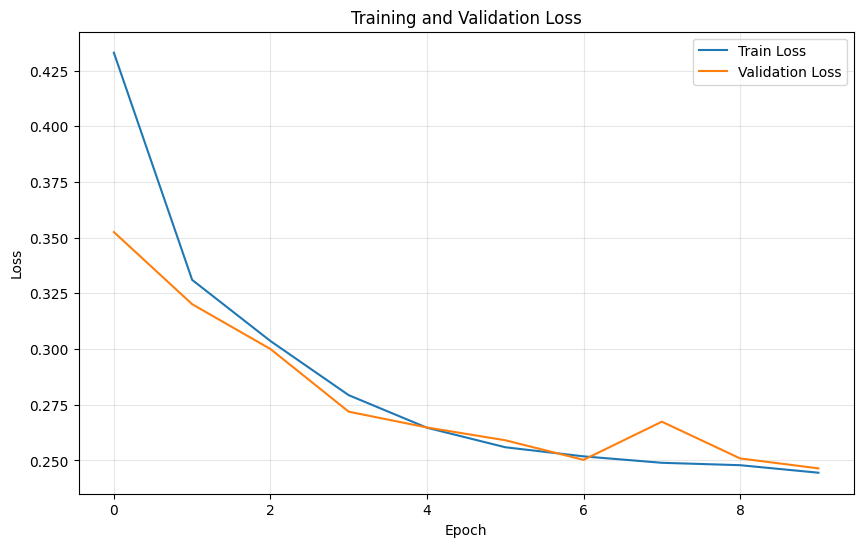

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.annotate("")
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()